In [1]:
from robot_vlp.config import INTERIM_DATA_DIR, PROCESSED_DATA_DIR
import pickle
import numpy as np
import keras
import robot_vlp.data.preprocessing as p
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

2024-10-07 08:54:34.643 | INFO     | robot_vlp.config:<module>:11 - PROJ_ROOT path is: /Users/tyrelglass/PhD/Repositories/robot-vlp


In [2]:
with open(PROCESSED_DATA_DIR/'model_train_test_data.pickle', 'rb') as handle:
    data_dic = pickle.load(handle)

train_files = data_dic['train_files']
valid_files = data_dic['valid_files']
test_files = data_dic['test_files']

X_train_data = data_dic['X_train_data']
X_test_data = data_dic['X_test_data']
X_valid_data = data_dic['X_valid_data']

y_train_data = data_dic['y_train_data']
y_test_data = data_dic['y_test_data']
y_valid_data = data_dic['y_valid_data']

X_train = data_dic['X_test']
X_valid = data_dic['X_valid']
X_test = data_dic['X_test']

y_train = data_dic['y_test']
y_valid = data_dic['y_valid']
y_test = data_dic['y_test']

In [3]:
X_train.shape, y_train.shape

((13483, 10, 5), (13483, 3))

In [59]:
from robot_vlp.config import MODELS_DIR
def ang_loss_fn(y_true, y_pred):
    return keras.losses.cosine_similarity(y_true, y_pred) + 1

model = keras.models.load_model(MODELS_DIR / 'model_01.keras',custom_objects={"ang_loss_fn": ang_loss_fn})

file_list = [file_name for file_name in INTERIM_DATA_DIR.iterdir() if file_name.stem[0] != "."]
train_files, valid_files, test_files = p.train_test_split_list(file_list)

X_scaler = p.build_scaler()

X_train_data, y_train_data = p.load_data(train_files)
X_valid_data, y_valid_data = p.load_data(valid_files)
X_test_data, y_test_data = p.load_data(test_files)

X_train_window, y_train = p.create_windows(X_train_data, y_train_data)
X_valid_window, y_valid = p.create_windows(X_valid_data, y_valid_data)
X_test_window, y_test = p.create_windows(X_test_data, y_test_data)

X_train = p.apply_scaler(X_train_window, X_scaler)
X_valid = p.apply_scaler(X_valid_window, X_scaler)
X_test = p.apply_scaler(X_test_window, X_scaler)

In [104]:
run = 4

print(train_files[run].name)

X_full = X_test_data[run]
y_full = y_test_data[run]

X_window, y_window = p.create_windows([X_full], [y_full], overlap = 0.9, window_len=10)

X_scaled = p.apply_scaler(X_window, X_scaler)

x_pre, y_pre, ang_pre = model.predict(X_scaled)

n_5_polygon_med_acc_err_2_shuffle_run3
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step


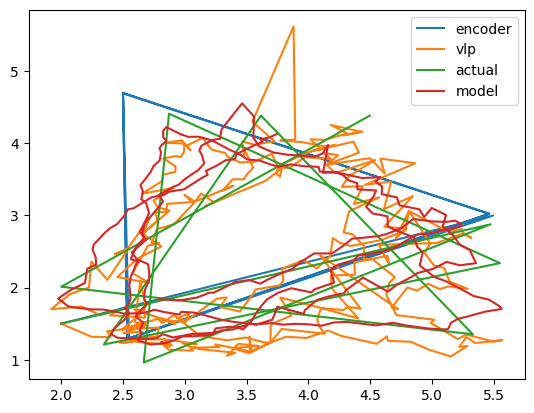

In [105]:
plt.plot(X_full[:,0],X_full[:,1], label = 'encoder')
plt.plot(X_full[:,3],X_full[:,4], label = 'vlp')
plt.plot(y_full[:,0],y_full[:,1], label = 'actual')

plt.plot(x_pre,y_pre, label = 'model')

plt.legend()

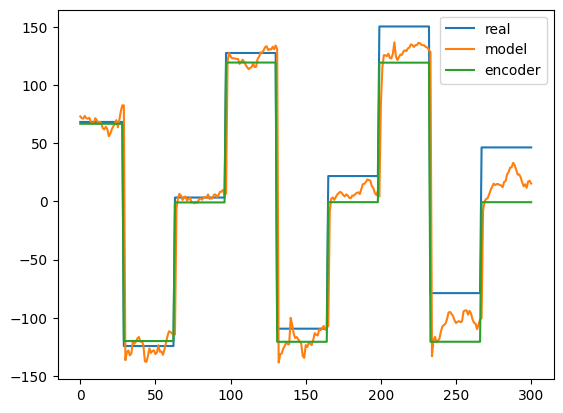

In [106]:
plt.plot(y_full[10:,2], label = 'real')
plt.plot(p.vector_to_ang(ang_pre, unit = 'degrees').numpy(), label = 'model')
plt.plot(X_full[10:,2], label = 'encoder')

plt.legend()


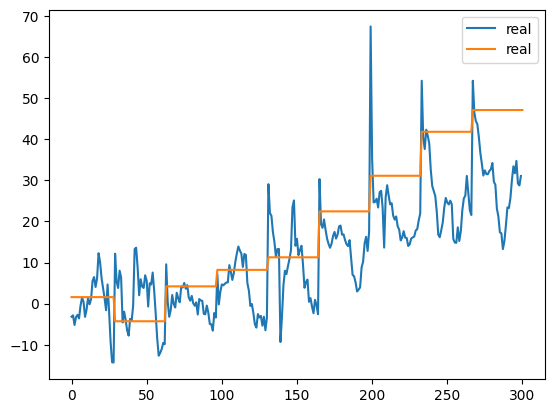

In [107]:
plt.plot(y_full[10:,2][:-1] - p.vector_to_ang(ang_pre, unit = 'degrees')[1:], label = 'real')
plt.plot(y_full[10:,2] - X_full[10:,2], label = 'real')
# plt.plot(p.vector_to_ang(ang_pre, unit = 'degrees').numpy(), label = 'model')
# plt.plot(X_full[10:,2], label = 'encoder')

plt.legend()


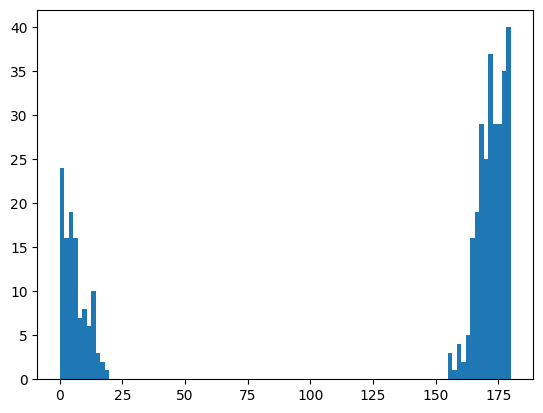

In [99]:
_= plt.hist((y_full[10:,2][:-1] - p.vector_to_ang(ang_pre, unit = 'degrees').numpy()[1:])%180 , bins = 100)
